In [133]:
# FITTING
from scipy.optimize import curve_fit
import numpy as np 
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

In [134]:
kT, F, lc, lp = 4.11, 9, 50, 0.44
z = np.linspace(0, 30, 500)  
a = 0.07

def U_wlc(z, lc, lp):
    return (kT / lp) * (-0.25 * (lc**2) / (z - lc) + z**2 / (2 * lc) - 0.25 * z) 

def U_fold(z, a, G0, U0, s, x_dag):
    return U0 * (1 - np.exp(-a * z))**2 + G0 * np.exp(-((z - x_dag)**2) / s)

def U_total(z, a, G0, U0, s, x_dag, k):
    return U_wlc(z, F, lc, lp) * k + U_fold(z, a, G0, U0, s, x_dag)

def U_logistic(z, G0, U0, s, x_dag, lp, lc, c):
    L = 1 / (1 + np.exp((x_dag - z)/c))
    return U_fold(z, a, G0, U0, s, x_dag) +  L * U_wlc(z, lc, lp) - F * z

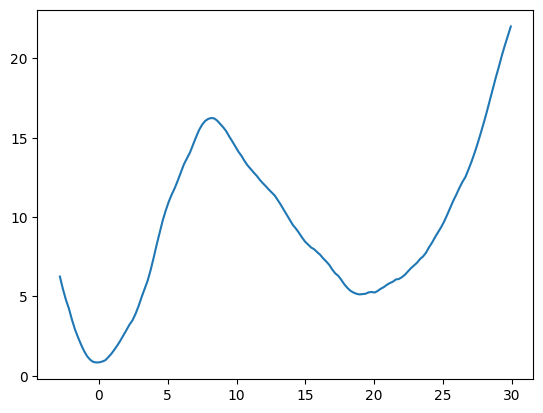

In [135]:
a, G0, U0, s, x_dag, lc, lp=  0.12, 8, 52, 12, 13, 50, 1

# upload data
df = pd.read_csv("Free_energy.txt", header=None, names=["U"])
x_values = -26.6 + 0.22 * np.arange(350)
df["x"] = x_values
x = df["x"]
y = df["U"]
y_smooth = savgol_filter(y, window_length=15, polyorder=3)
x = np.array(x)
y_smooth = np.array(y_smooth)

# fit mask : optimize the fit 
mask = (x > -3)& (x < 30)
x_fit = x[mask]
y_fit = y_smooth[mask]
plt.plot(x_fit, y_fit)

[17.89943167 60.         18.63490764  7.4         0.58267454 46.29123259
  3.38955018]


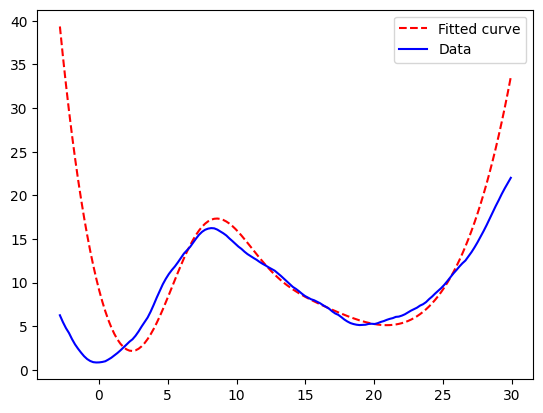

In [136]:
# fit 

weights = np.ones_like(x_fit)
weights[(x_fit > 0) & (x_fit < 25)] = 4
lower_bounds = [0, 25, 6, 7.4, 0.4, 40, 1.6]
upper_bounds = [50, 60, 19, 10,  0.9,  50, 4]
p0 = [10, 30, 6.44, 8, 0.53, 49, 2.2]  # G0, U0, s, x_dag, lp, lc, c

popt, pcov = curve_fit(U_logistic, x_fit, y_fit, p0=p0, sigma = 1/weights,  bounds = (lower_bounds, upper_bounds), maxfev=10000)
G0_fit, U0_fit, s_fit, x_dag_fit, lp_fit, lc_fit, c_fit= popt
U_fit = U_logistic(x_fit, *popt)

plt.plot(x_fit, U_fit , label='Fitted curve', color='red', linestyle='--') 
plt.plot(x_fit, y_fit, label='Data', color='blue')
# plt.plot(x_fit, U_fold(x_fit, *popt[0:5]), label='Folded', color='green', linestyle='--')  
# plt.plot(x_fit, U_wlc(x_fit, F, lc, lp), label='WLC', color='orange', linestyle='--')
plt.legend()

print (popt)

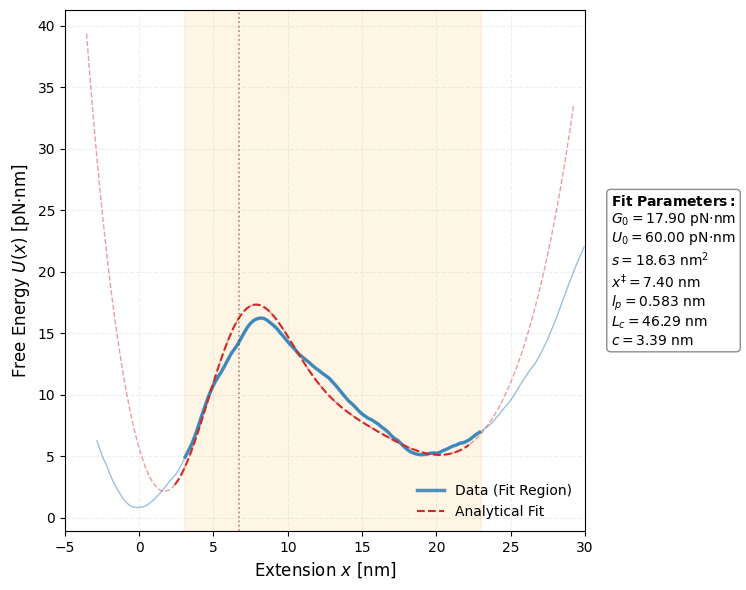

In [137]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. PARAMETRI FISSI ---
popt = [17.89943167, 60., 18.63490764, 7.4, 0.58267454, 46.29123259, 3.38955018]
G0_f, U0_f, s_f, x_dag_f, lp_f, lc_f, c_f = popt

# --- 2. CONFIGURAZIONE REGIONE E SHIFT ---
visual_shift = 0.7 
x_start, x_end = 3, 23
x_model_shifted = x_fit - visual_shift
y_fit_vals = U_logistic(x_fit, *popt)

# --- 3. PLOT PROFESSIONALE ---
plt.figure(figsize=(9, 6))

# A. REGIONE EVIDENZIATA IN ARANCIONE (Sotto tutto)
plt.axvspan(x_start, x_end, color='orange', alpha=0.1, zorder=1)

# B. LINEE CONTINUE SFONDO (Alpha basso per evitare linee rette di congiunzione)
plt.plot(x_fit, y_fit, color='#1f77b4', alpha=0.45, linewidth=1, zorder=2)
plt.plot(x_model_shifted, y_fit_vals, color='#d62728', linestyle='--', alpha=0.45, linewidth=1, zorder=2)

# C. SEGMENTI EVIDENZIATI (Sopra le linee sbiadite)
mask_in = (x_fit >= x_start) & (x_fit <= x_end)

plt.plot(x_fit[mask_in], y_fit[mask_in], color='#1f77b4', alpha=0.8, linewidth=2.5, label='Data (Fit Region)', zorder=3)
plt.plot(x_model_shifted[mask_in], y_fit_vals[mask_in], color='#d62728', linestyle='--', linewidth=1.5, label='Analytical Fit', zorder=3)

# D. LINEA TS
plt.axvline(x=x_dag_f - visual_shift, color='darkred', linestyle=':', alpha=0.5, linewidth=1.2, zorder=4)

# E. TEXT INFO BOX
stats_text = (
    r"$\mathbf{Fit\ Parameters:}$" + "\n" +
    rf"$G_0 = {G0_f:.2f}$ pN$\cdot$nm" + "\n" +
    rf"$U_0 = {U0_f:.2f}$ pN$\cdot$nm" + "\n" +
    rf"$s = {s_f:.2f}$ nm$^2$" + "\n" +
    rf"$x^{{\ddagger}} = {x_dag_f:.2f}$ nm" + "\n" +
    rf"$l_p = {lp_f:.3f}$ nm" + "\n" +
    rf"$L_c = {lc_f:.2f}$ nm" + "\n" +
    rf"$c = {c_f:.2f}$ nm"
)

plt.annotate(stats_text, xy=(1.05, 0.5), xycoords='axes fraction', 
             va='center', bbox=dict(boxstyle="round", fc="white", ec="gray", alpha=0.9))

# --- 4. FORMATTAZIONE ---
plt.xlabel(r'Extension $x$ [nm]', fontsize=12)
plt.ylabel(r'Free Energy $U(x)$ [pN$\cdot$nm]', fontsize=12)
plt.xlim(-5, 30)
plt.grid(True, linestyle='--', alpha=0.2, zorder=0)
plt.legend(loc='lower right', frameon=False, fontsize=10)
plt.tight_layout(rect=[0, 0, 0.85, 1]) # Spazio per il box a destra
plt.savefig("Hybrid.pdf")

plt.show()

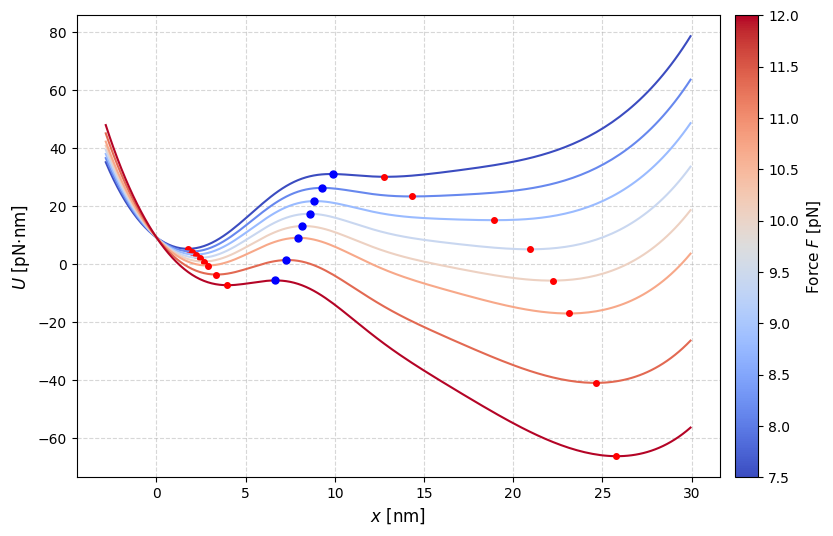

rho_list = [2.846153846153848, 1.4347826086956512, 0.6521739130434786, 0.5000000000000003, 0.3906249999999996, 0.33333333333333326, 0.2278481012658229, 0.13793103448275845]


In [157]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import matplotlib.cm as cm

# --- PARAMETRI ---
F_list = [7.5, 8, 8.5, 9, 9.5, 10, 11, 12]
popt = [17.89943167, 60.0, 18.63490764, 7.4, 0.58267454, 46.29123259, 3.38955018]

# Inizializziamo una sola figura e un set di assi
fig, ax = plt.subplots(figsize=(10, 6))

rho_list = []
minima_x_list = []
maxima_y_list = []

# Definiamo la colormap
cmap = cm.coolwarm
colors = cmap(np.linspace(0, 1, len(F_list)))

for i, F in enumerate(F_list):
    # Calcolo U_fit (mantenendo la tua logica originale)
    U_fit = U_logistic(x_fit, *popt)
    
    minima_indices, _ = find_peaks(-U_fit) 
    minima_x = x_fit[minima_indices]
    minima_y = U_fit[minima_indices]

    maxima_indices, _ = find_peaks(U_fit)
    maxima_x = x_fit[maxima_indices]
    maxima_y = U_fit[maxima_indices]
    
    minima_x_list.append(minima_x)
    maxima_y_list.append(maxima_y)  

    # Plottiamo sugli assi 'ax'
    ax.plot(x_fit, U_fit, color=colors[i], linewidth=1.5)
    ax.plot(minima_x, minima_y, 'ro', markersize=4)
    ax.plot(maxima_x, maxima_y, 'bo', markersize=5)

    # Compute rho
    if len(minima_x) >= 2 and len(maxima_x) >= 1:
        X1 = np.abs(minima_x[0] - maxima_x[0])
        X2 = np.abs(minima_x[1] - maxima_x[0])
        rho_list.append(X1 / X2)

# --- AGGIUNTA COLORBAR (Sistemata) ---
norm = plt.Normalize(vmin=min(F_list), vmax=max(F_list))
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

# Specifichiamo 'ax=ax' per dire alla colorbar da dove prendere lo spazio
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label('Force $F$ [pN]', fontsize=11)

# --- FORMATTAZIONE ---
ax.set_xlabel("$x$ [nm]", fontsize=12)
ax.set_ylabel("$U$ [pN$\cdot$nm]", fontsize=12)
ax.grid(True, linestyle="--", alpha=0.5)

plt.savefig("wlcShift.pdf", bbox_inches='tight')
plt.show()

print("rho_list =", rho_list)

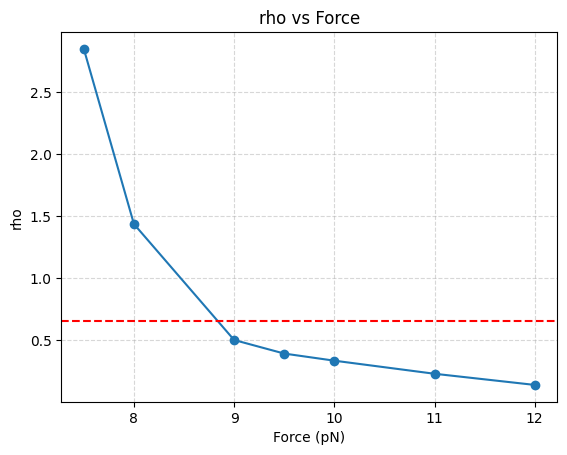

In [139]:
colors = plt.get_cmap('tab10')
plt.plot(F_list, rho_list, 'o-', color = colors(0))
plt.axhline(y= 0.65, color='r', linestyle='--')
plt.xlabel("Force (pN)")
plt.ylabel("rho")    
plt.title("rho vs Force")   
plt.grid(True, linestyle="--", alpha=0.5)

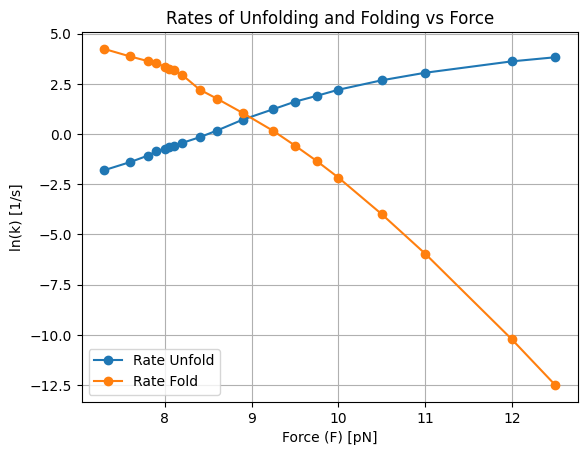

In [140]:
# MFPT Simulation

from scipy.integrate import quad
D = 1500
kT = 4.11
F_list = [7.3, 7.6, 7.8,7.9, 8, 8.05, 8.1, 8.2, 8.4, 8.6, 8.9, 9.25, 9.5, 9.75, 10, 10.5, 11, 12, 12.5]

def mfpt(x, x_a, x_b, U_logistic, kT, D, popt, F):    

    def inner_integral(y):
        result, _ = quad(lambda z: np.exp(-U_logistic(z,  *popt) / kT), x_a, y)
        return result
    def outer_integral():
        result, _ = quad(lambda y: np.exp(U_logistic(y, *popt) / kT) * inner_integral(y), x, x_b)
        return result

    return outer_integral() / D

rate_unfold_list = []
rate_fold_list = []
force_list = []

for F in F_list:

    U_fit = U_logistic(x_fit, *popt)
    minima_indices, _ = find_peaks(- U_fit) 
    minima_x = x_fit[minima_indices]
    minima_y = U_fit[minima_indices]

    maxima_indices, _ = find_peaks(U_fit)  # Trova i massimi
    maxima_x = x_fit[maxima_indices]
    maxima_y = U_fit[maxima_indices]

   #plt.plot(x_fit, U_total_fit(x_fit, *popt, F), label=f'F = {F} pN')
    mfpt_value = mfpt(minima_x[0], minima_x[0] - 1, minima_x[1], U_logistic, kT, D, popt, F)
    rate_unfold = 1 / mfpt_value
    
    mfpt_value2 = mfpt(minima_x[1], minima_x[1] +1, minima_x[0], U_logistic, kT, D, popt, F)
    rate_fold = 1 / mfpt_value2
    
    rate_unfold_list.append(rate_unfold)
    rate_fold_list.append(rate_fold)
    force_list.append(F)

plt.plot(force_list, np.log(rate_unfold_list), label="Rate Unfold", marker='o')
plt.plot(force_list, np.log(rate_fold_list), label="Rate Fold", marker='o')
plt.xlabel("Force (F) [pN]")
plt.ylabel("ln(k) [1/s]")
plt.title("Rates of Unfolding and Folding vs Force")
plt.legend()
plt.grid(True)
plt.show()


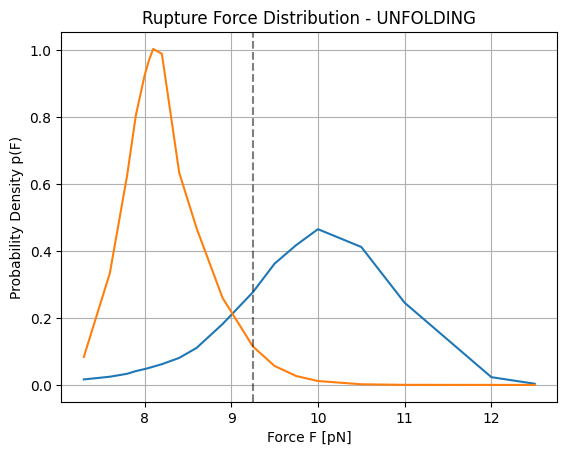

In [141]:
from scipy.integrate import cumtrapz

kappa_s = 0.1  # stiffness della molla [pN/nm]
v = 100        # velocità [nm/s]
F_dot = kappa_s * v  # loading rate costante
#########-------------ASK_RAFA


tau_list = [1 / k for k in rate_unfold_list]
tau_fold = [1 / k for k in rate_fold_list]

x = F_list
tau_array = np.array(tau_list)
tau_f_array = np.array(tau_fold)

y_f  = 1 / (- F_dot * tau_f_array)
y = 1 / (F_dot * tau_array)

integral_f = cumtrapz(y_f, x, initial=0)  # integrale comulativo reg trapezio
integral = cumtrapz(y, x, initial=0)  # integrale comulativo reg trapezio

p_F = np.exp(-integral) / (F_dot * tau_array)
p_U = np.exp(-integral_f) / (- F_dot * tau_f_array)

# Normalizzazione: ∫p(F)dF = 1
area = np.trapz(p_F, x)
are_F = np.trapz(p_U, x)

p_F_normalized = p_F / area
p_U_norm = p_U / are_F

# Plot
plt.plot(x, p_F_normalized)
plt.plot(x, p_U_norm)
plt.xlabel("Force F [pN]")
plt.ylabel("Probability Density p(F)")
plt.axvline(x = 9.25, linestyle='--', c ="black",  alpha = 0.5)
plt.title("Rupture Force Distribution - UNFOLDING")
plt.grid(True)
plt.show()